# 05 — Feature-Based Model (XGBoost)

Parts 5–6: feature engineering (sensor/weather/time/lag/rolling features) and a tuned XGBoost regressor, evaluated with the same rolling design (recursive within each 24h block for short lags — see `src/appliance_energy/models/feature_models.py`). Tuning takes ~1 minute, so this notebook displays the already-computed results from `scripts/run_feature_model.py`.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
from IPython.display import Image, display


## Best hyperparameters (RandomizedSearchCV, TimeSeriesSplit)

In [2]:
print(open('../outputs/model_objects/feature_model_best_params.txt').read())

{'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


## Feature importance

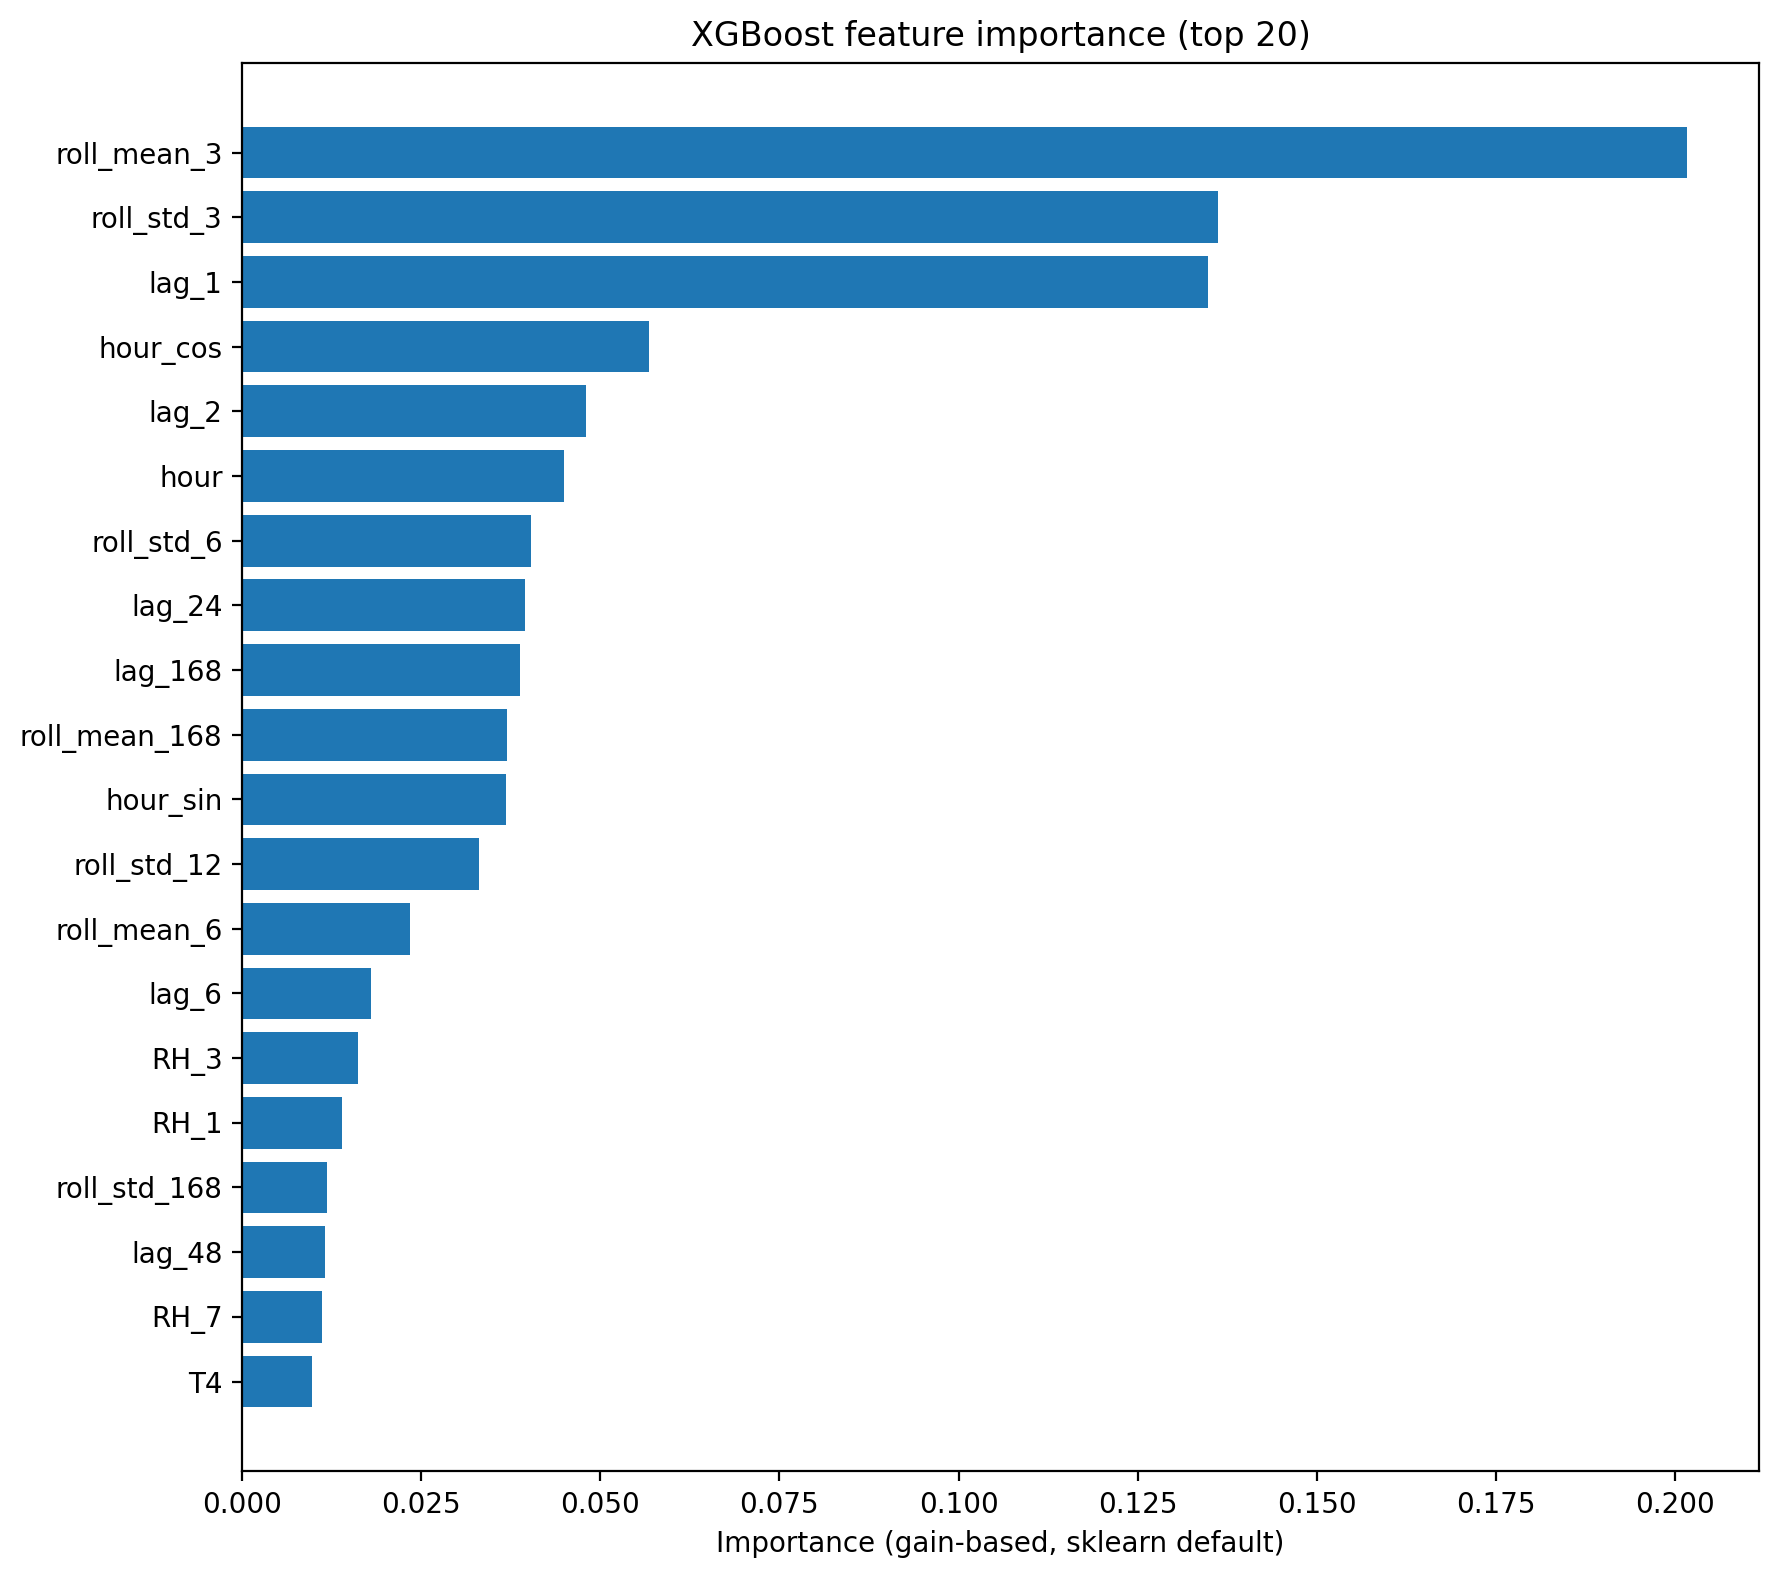

In [3]:
display(Image(filename='../outputs/figures/feature_importance.png'))

The target's own recent history (short lags, rolling mean/std) dominates; sensor/weather readings rank far lower.

## Rolling forecast

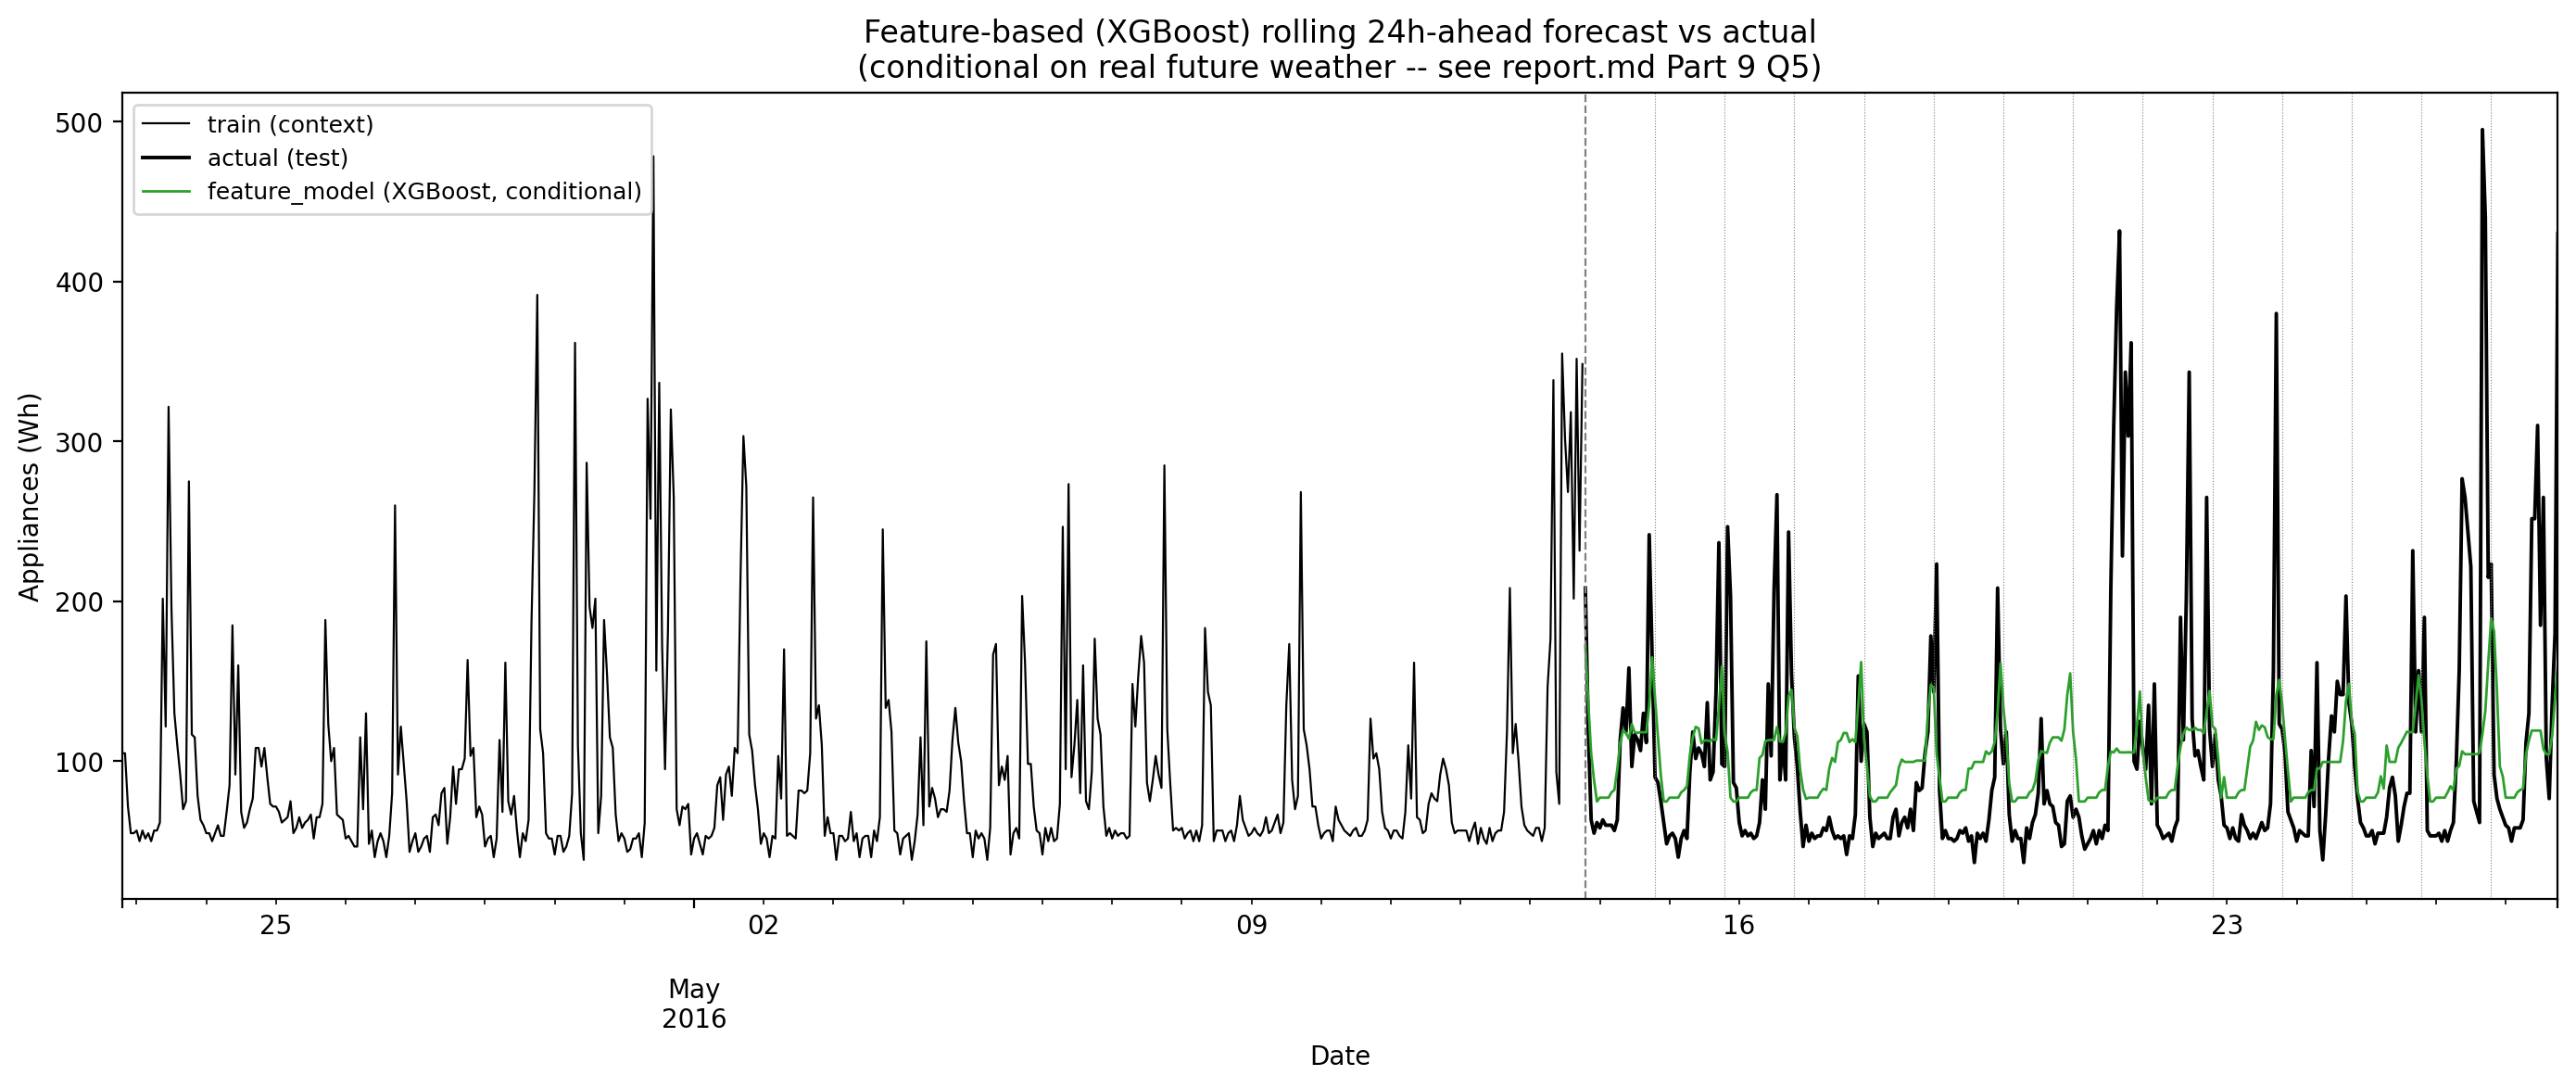

In [4]:
display(Image(filename='../outputs/figures/feature_model_forecast.png'))

## Results

In [5]:
comparison = pd.read_csv('../outputs/metrics/model_comparison.csv')
comparison[comparison['model'].isin(['feature_model', 'sarimax', 'seasonal_naive_weekly'])]

,model,MAE,RMSE,MASE,Bias
0,sarimax,38.055428,65.734392,0.943346,-4.972041
3,feature_model,42.536922,66.873291,1.054437,0.843181
4,seasonal_naive_weekly,43.457341,81.408880,1.077253,-13.159722
